# Superstore Data Science Tutorial (School Style)

This notebook teaches data analysis and machine learning in very simple steps.

How to use this notebook:
1. Read markdown first.
2. Run one code cell at a time.
3. Check output before moving to the next cell.
4. Do the mini exercise in each section.

## Lesson 0: What we are trying to solve

We have Superstore order data.

We want to answer:
- Which category gives high sales?
- Which part of business gives low or negative profit?
- Does discount hurt profit?
- Can we predict profit using machine learning?

## Lesson 1: Import libraries

We load tools for data handling, charts, and ML.

In [47]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


### Mini Exercise
Write 1 line: Why do we import pandas?

## Lesson 2: Load the dataset

This code tries common file paths and loads the CSV.

In [48]:
from pathlib import Path

# NOTE: This notebook uses the corrected CLEAN dataset with all valid records retained.
# Data engineering decisions:
#   - Keep all 51,290 valid business rows (no duplicate-row deletion required)
#   - Remove only spreadsheet artifacts (empty padding rows and Unnamed summary columns)
#   - Repair mixed date formats using robust parsing (default + dayfirst fallback)
#   - Standardize schema to clean lowercase_underscore columns

possible_paths = [
    Path('SuperStoreOrders_SuperStoreOrders.csv'),
    Path('../SuperStoreOrders_SuperStoreOrders.csv'),
    Path('data/raw/SuperStoreOrders_SuperStoreOrders.csv')
]

file_path = None
for p in possible_paths:
    if p.exists():
        file_path = p
        break

if file_path is None:
    raise FileNotFoundError('CSV file not found. Please update possible_paths.')

df = pd.read_csv(file_path)

# Defensive date parsing for mixed-format sources.
for dcol in ['order_date', 'ship_date']:
    if dcol in df.columns:
        p1 = pd.to_datetime(df[dcol], errors='coerce')
        p2 = pd.to_datetime(df[dcol], errors='coerce', dayfirst=True)
        df[dcol] = p1.fillna(p2)

print('Loaded from:', file_path)
print('Shape:', df.shape)
print('Duplicate rows:', int(df.duplicated().sum()))
print(f'Date range: {df["order_date"].min()} to {df["order_date"].max()}')
df.head()

Loaded from: ..\SuperStoreOrders_SuperStoreOrders.csv
Shape: (51290, 22)
Duplicate rows: 0
Date range: 2011-01-01 00:00:00 to 2014-12-31 00:00:00


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0


### Mini Exercise
How many rows and columns are in your data?

## Lesson 3: Understand the data (Simple -> Detailed)

In separate steps, we will check:
1. Dataframe shape and first rows
2. Data types
3. Statistical summary
4. Missing values
5. Duplicate rows

In [49]:
print('Dataset shape (rows, columns):', df.shape)
print('Total columns:', len(df.columns))
print('\nFirst 5 rows:')
display(df.head())

print('\nColumn names:')
print(df.columns.tolist())

Dataset shape (rows, columns): (51290, 22)
Total columns: 22

First 5 rows:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0



Column names:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'country', 'state', 'market', 'region', 'product_id', 'product_name', 'category', 'sub_category', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'sequence_number']


### Step 3.1: Data types check

This helps us identify numeric, text, and date-like fields before cleaning.

In [50]:
dtype_df = df.dtypes.to_frame('dtype')
display(dtype_df.T)

print('Data type counts:')
print(df.dtypes.value_counts())

,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
dtype,object,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,int64,float64,float64,float64,float64,object,float64,float64


Data type counts:
object            13
float64            6
datetime64[ns]     2
int64              1
Name: count, dtype: int64


### Step 3.2: Basic statistical summary

This gives numeric distribution basics: count, mean, std, min, quartiles, and max.

In [51]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
discount,51290.0,0.145278,0.214113,0.000,0.00,0.00,0.20,0.900
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570
year,51290.0,2012.777208,1.098931,2011.000,2012.00,2013.00,2014.00,2014.000
sequence_number,51290.0,25645.500000,14806.291990,1.000,12823.25,25645.50,38467.75,51290.000


### Step 3.3: Missing values check

We inspect missing values before cleaning so we know the data quality status.

In [52]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_columns = missing_counts[missing_counts > 0]

total_missing_cells = int(missing_counts.sum())
total_cells = int(df.shape[0] * df.shape[1])
missing_pct = (total_missing_cells / total_cells * 100) if total_cells else 0.0

print(f'Total missing cells: {total_missing_cells:,}')
print(f'Dataset-wide missing %: {missing_pct:.2f}%')

if not missing_columns.empty:
    missing_df = missing_columns.to_frame('missing_count')
    missing_df['missing_pct'] = (missing_df['missing_count'] / len(df) * 100).round(2)
    display(missing_df)
else:
    print('No missing values found.')

Total missing cells: 0
Dataset-wide missing %: 0.00%
No missing values found.


### Step 3.4: Duplicate rows check

Duplicates can distort EDA and ML if not handled before modeling.

In [53]:
dup_count = int(df.duplicated().sum())
print(f'Duplicate rows: {dup_count:,}')
print(f'Duplicate ratio: {(dup_count / len(df) * 100):.2f}%')

Duplicate rows: 0
Duplicate ratio: 0.00%


## Lesson 4: Clean the data (Transformation step)

Now we perform cleaning in one focused block:
- Standardize column names
- Convert date columns to datetime
- Remove duplicate rows
- Create aliases and helper columns for analysis

In [54]:
# Step 4.1: Column format standardization + date parsing
before_rows = len(df)

# Standardize names to snake_case-like format
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

# Convert date-like columns to datetime
for c in df.columns:
    if 'date' in c.lower():
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('Rows before cleaning:', before_rows)
print('Column format updated and date parsing completed.')
print('Sample columns:', df.columns[:12].tolist())

Rows before cleaning: 51290
Column format updated and date parsing completed.
Sample columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'country', 'state', 'market', 'region', 'product_id', 'product_name']


### Step 4.2: Remove duplicate rows

Now we remove duplicates so EDA and ML are based on unique transaction records.

In [55]:
dup_before = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

print(f'Duplicates removed: {dup_before:,}')
print(f'Rows after dedup: {len(df):,}')

Duplicates removed: 0
Rows after dedup: 51,290


### Step 4.3: Create analysis-ready columns

Here we create friendly aliases and helper columns for business and ML analysis.

In [56]:
# Create friendly aliases so the next lessons work with different CSV column styles.
alias_map = {
    'sales': 'Sales',
    'profit': 'Profit',
    'discount': 'Discount',
    'order_date': 'Order_Date',
    'ship_date': 'Ship_Date',
    'category': 'Category',
    'sub_category': 'Sub_Category',
    'segment': 'Segment',
    'region': 'Region',
    'state': 'State',
    'product_name': 'Product_Name',
    'customer_name': 'Customer_Name',
    'order_id': 'Order_ID',
    'customer_id': 'Customer_ID',
    'row_id': 'Row_ID'
}

for src, dst in alias_map.items():
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]

# Ensure key numeric columns are truly numeric.
for num_col in ['Sales', 'Profit', 'Discount']:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

if 'Order_Date' in df.columns:
    df['Order_Year'] = df['Order_Date'].dt.year
    df['Order_Month'] = df['Order_Date'].dt.month

if {'Sales', 'Profit'}.issubset(df.columns):
    df['Profit_Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], np.nan)

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (51290, 38)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number,Sales,Profit,Discount,Order_Date,Ship_Date,Category,Sub_Category,Segment,Region,State,Product_Name,Customer_Name,Order_ID,Order_Year,Order_Month,Profit_Margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0,408,106.140,0.0,2011-01-01,2011-06-01,Office Supplies,Storage,Consumer,Africa,Constantine,"Tenex Lockers, Blue",Toby Braunhardt,AG-2011-2040,2011,1,0.260147
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0,120,36.036,0.1,2011-01-01,2011-08-01,Office Supplies,Supplies,Consumer,Oceania,New South Wales,"Acme Trimmer, High Speed",Joseph Holt,IN-2011-47883,2011,1,0.300300
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0,66,29.640,0.0,2011-01-01,2011-05-01,Office Supplies,Storage,Consumer,EMEA,Budapest,"Tenex Box, Single Width",Annie Thurman,HU-2011-1220,2011,1,0.449091
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0,45,-26.055,0.5,2011-01-01,2011-05-01,Office Supplies,Paper,Home Office,North,Stockholm,"Enermax Note Cards, Premium",Eugene Moren,IT-2011-3647632,2011,1,-0.579000
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0,114,37.770,0.1,2011-01-01,2011-08-01,Furniture,Furnishings,Consumer,Oceania,New South Wales,"Eldon Light Bulb, Duo Pack",Joseph Holt,IN-2011-47883,2011,1,0.331316


### Mini Exercise
Explain in one sentence: Why do we convert dates before trend analysis?

## Lesson 5: Basic statistics

This gives quick summary (mean, min, max, etc.) for numeric columns.

In [57]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000000,31.00,85.000000,251.000000,22638.0000
quantity,51290.0,3.476545,2.278766,1.000000,2.00,3.000000,5.000000,14.0000
discount,51290.0,0.145278,0.214113,0.000000,0.00,0.000000,0.200000,0.9000
profit,51290.0,28.641740,174.424113,-6599.978000,0.00,9.240000,36.810000,8399.9760
shipping_cost,51290.0,26.375915,57.296804,0.000000,2.61,7.790000,24.450000,933.5700
year,51290.0,2012.777208,1.098931,2011.000000,2012.00,2013.000000,2014.000000,2014.0000
sequence_number,51290.0,25645.500000,14806.291990,1.000000,12823.25,25645.500000,38467.750000,51290.0000
Sales,51290.0,246.498440,487.567175,0.000000,31.00,85.000000,251.000000,22638.0000
Profit,51290.0,28.641740,174.424113,-6599.978000,0.00,9.240000,36.810000,8399.9760
Discount,51290.0,0.145278,0.214113,0.000000,0.00,0.000000,0.200000,0.9000


## Lesson 6: First charts (easy visual analysis)

We plot distributions for Sales, Profit, and Discount.

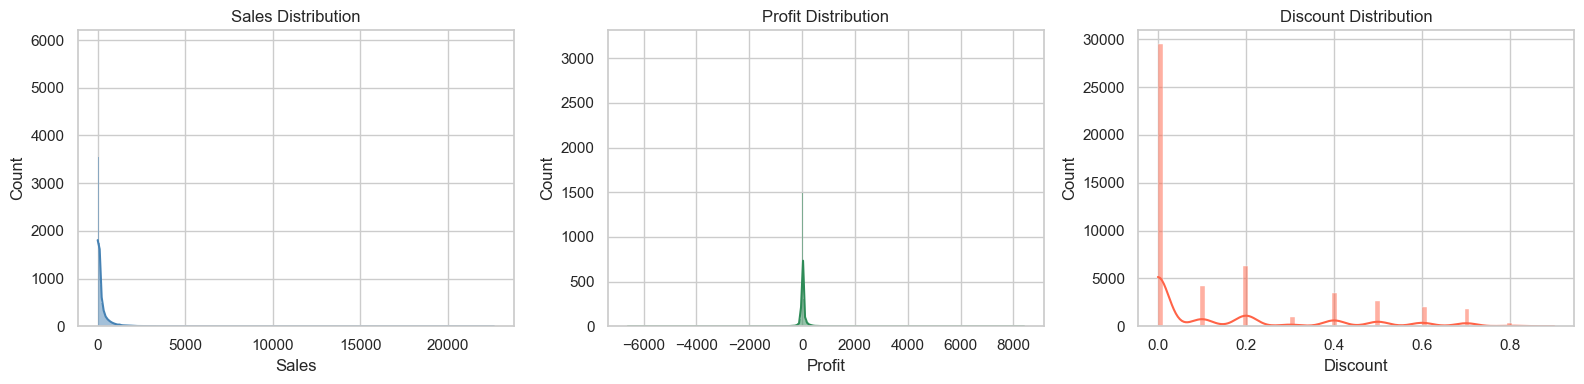

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if 'Sales' in df.columns:
    sns.histplot(df['Sales'], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Sales Distribution')

if 'Profit' in df.columns:
    sns.histplot(df['Profit'], kde=True, ax=axes[1], color='seagreen')
    axes[1].set_title('Profit Distribution')

if 'Discount' in df.columns:
    sns.histplot(df['Discount'], kde=True, ax=axes[2], color='tomato')
    axes[2].set_title('Discount Distribution')

plt.tight_layout()
plt.show()

## Lesson 7: Business question analysis

Now we answer practical business questions.

In [59]:
if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Category summary:')
    display(cat)

if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    reg = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Region summary:')
    display(reg)

if {'Sub_Category', 'Profit'}.issubset(df.columns):
    loss_sub = df.groupby('Sub_Category')['Profit'].sum().sort_values().head(10)
    print('Top 10 loss-making sub-categories:')
    display(loss_sub.to_frame('Total_Profit'))

Category summary:


,Sales,Profit
Category,,
Technology,4744691,663778.73318
Furniture,4110884,286782.25380
Office Supplies,3787330,518473.83430


Region summary:


,Sales,Profit
Region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,121666.64200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


Top 10 loss-making sub-categories:


,Total_Profit
Sub_Category,
Tables,-64083.3887
Fasteners,11525.4241
Labels,15010.5120
Supplies,22583.2631
Envelopes,29601.1163
Furnishings,46967.4255
Art,57953.9109
Machines,58867.8730
Paper,59207.6827


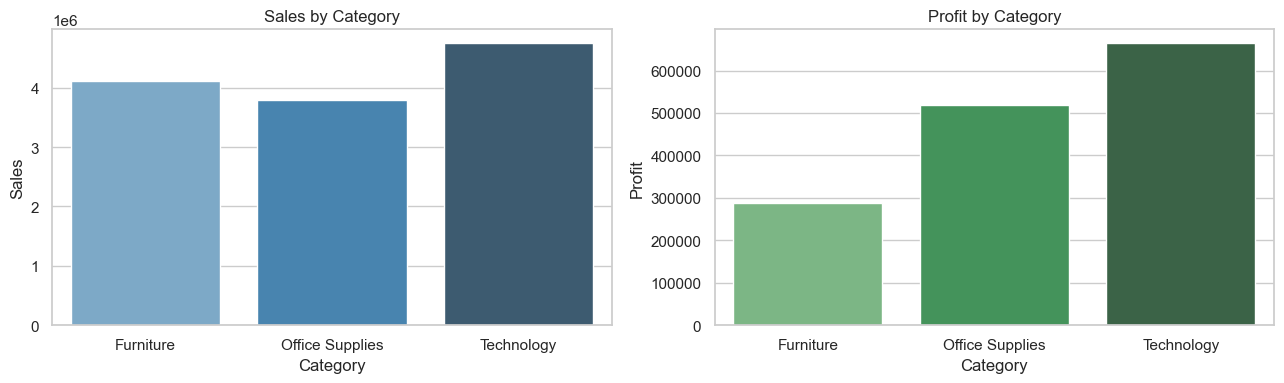

In [60]:
if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.barplot(data=category_summary, x='Category', y='Sales', ax=axes[0], palette='Blues_d')
    axes[0].set_title('Sales by Category')

    sns.barplot(data=category_summary, x='Category', y='Profit', ax=axes[1], palette='Greens_d')
    axes[1].set_title('Profit by Category')

    plt.tight_layout()
    plt.show()

## Lesson 8: Discount vs Profit check

Important idea: higher discount can reduce profit.

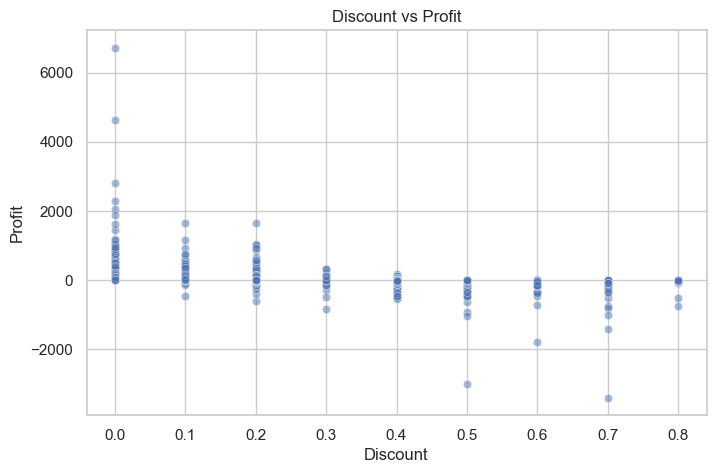

In [61]:
if {'Discount', 'Profit'}.issubset(df.columns):
    sample_df = df.sample(min(4000, len(df)), random_state=42)
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=sample_df, x='Discount', y='Profit', alpha=0.5)
    plt.title('Discount vs Profit')
    plt.show()

### Mini Exercise
After looking at the chart, write your observation in 1-2 lines.

## Lesson 9: Time trend analysis

We check monthly sales and monthly profit.

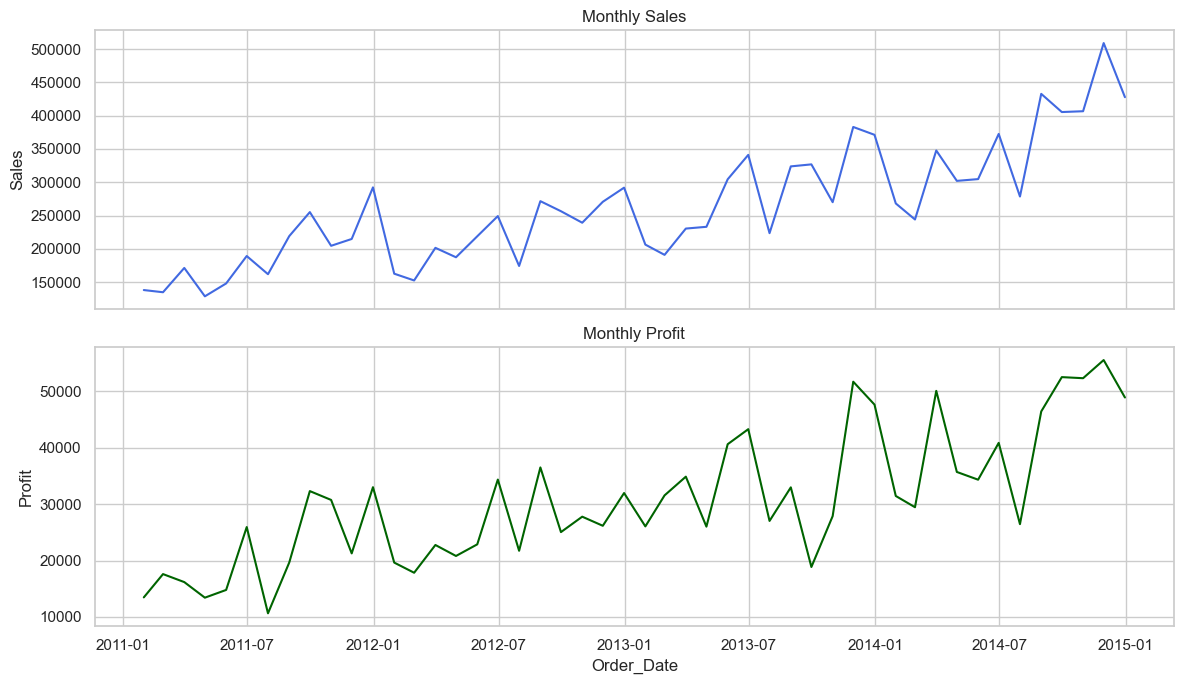

In [62]:
if {'Order_Date', 'Sales', 'Profit'}.issubset(df.columns):
    monthly = (
        df.set_index('Order_Date')
          .resample('M')[['Sales', 'Profit']]
          .sum()
          .reset_index()
    )

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    sns.lineplot(data=monthly, x='Order_Date', y='Sales', ax=ax[0], color='royalblue')
    ax[0].set_title('Monthly Sales')

    sns.lineplot(data=monthly, x='Order_Date', y='Profit', ax=ax[1], color='darkgreen')
    ax[1].set_title('Monthly Profit')

    plt.tight_layout()
    plt.show()

## Lesson 10: Prepare data for ML (very simple version)

Goal: predict Profit from other columns.

Think like this:
- Input (X) = information we already know about an order
- Output (y) = Profit value we want to predict

In simple words:
- `X` is question data
- `y` is answer data

Important rule for clean learning:
- Do not keep ID columns (like Order_ID, Customer_ID) as model inputs
- IDs are names, not useful patterns for prediction

In [63]:
if 'Profit' not in df.columns:
    raise ValueError('Profit column is required for ML')

# Fast-mode switches: keep notebook responsive on low-end machines.
FAST_MODE = True
MAX_TRAIN_ROWS = 30000

# 1) Target variable (what we want to predict)
y = df['Profit'].copy()

# 2) Feature table (input columns)
drop_candidates = [
    'Profit', 'profit',
    'Row_ID', 'row_id', 'S_no',
    'Order_ID', 'order_id',
    'Customer_ID', 'customer_id',
    'Customer_Name', 'customer_name',
    'Product_Name', 'product_name',
    'Product_ID', 'product_id',
    'Unnamed:_29', 'Unnamed:_30', 'Unnamed:_31',
    'year'
]
drop_cols = [c for c in drop_candidates if c in df.columns]
X = df.drop(columns=drop_cols, errors='ignore').copy()

# 3) Keep only rows where target is available
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Optional sampling for faster model iterations while preserving distribution.
if FAST_MODE and len(X) > MAX_TRAIN_ROWS:
    sampled_idx = X.sample(n=MAX_TRAIN_ROWS, random_state=42).index
    X = X.loc[sampled_idx].copy()
    y = y.loc[sampled_idx].copy()

# 4) Find numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Drop very high-cardinality categorical columns that slow one-hot encoding heavily.
high_card_cols = [c for c in cat_cols if X[c].nunique(dropna=True) > 300]
if high_card_cols:
    X = X.drop(columns=high_card_cols)
    cat_cols = [c for c in cat_cols if c not in high_card_cols]

# Use category dtype to reduce memory and speed up encoding.
for col in cat_cols:
    X[col] = X[col].astype('string').fillna('missing').astype('category')

print('X shape:', X.shape)
print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))
print('Dropped high-cardinality columns:', high_card_cols[:8], '...' if len(high_card_cols) > 8 else '')
print('Sample feature columns:', X.columns[:10].tolist())
print('FAST_MODE:', FAST_MODE)

X shape: (30000, 22)
Numeric columns: 10
Categorical columns: 12
Dropped high-cardinality columns: ['order_date', 'ship_date', 'state', 'Order_Date', 'Ship_Date', 'State'] 
Sample feature columns: ['ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'sales', 'quantity', 'discount']
FAST_MODE: True


In [64]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

print('ML preprocessor is ready')

ML preprocessor is ready


## Lesson 11: Train ML models (Regression)

This is the first advanced step, but we keep it simple.

What is supervised learning?
- We train using known answers.
- Here, known answer is `Profit`.

What is regression?
- Regression predicts numbers.
- Example: predict profit value for a new order.

Models used:
- Linear Regression: simple baseline model
- Random Forest Regressor: stronger model for non-linear patterns

How to read metrics:
- MAE: average absolute error (smaller is better)
- RMSE: larger mistakes get more penalty (smaller is better)
- R2: goodness of fit (closer to 1 is better)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_trees = 60 if ('FAST_MODE' in globals() and FAST_MODE) else 200

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=rf_trees,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    trained_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MAE,RMSE,R2
1,RandomForestRegressor,2.380203,64.728932,0.865353
0,LinearRegression,52.827056,146.754116,0.307882


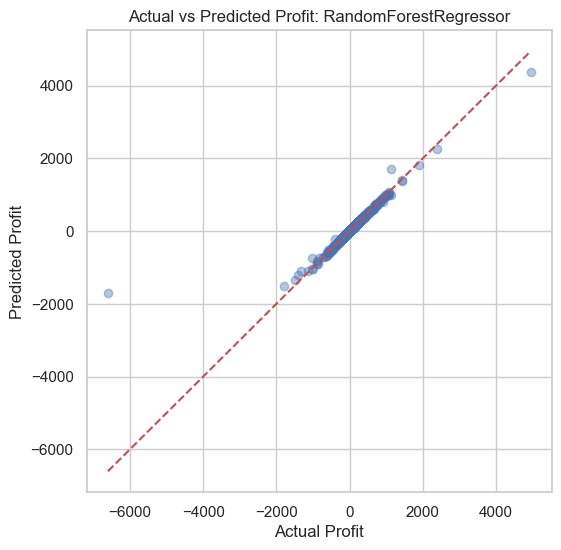

In [66]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = trained_pipes[best_model_name]
pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_best, alpha=0.4)
min_val = min(y_test.min(), pred_best.min())
max_val = max(y_test.max(), pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit: ' + best_model_name)
plt.show()

## Lesson 12: Explain model drivers (Feature Importance)

We use Random Forest feature importance to find key factors affecting profit.

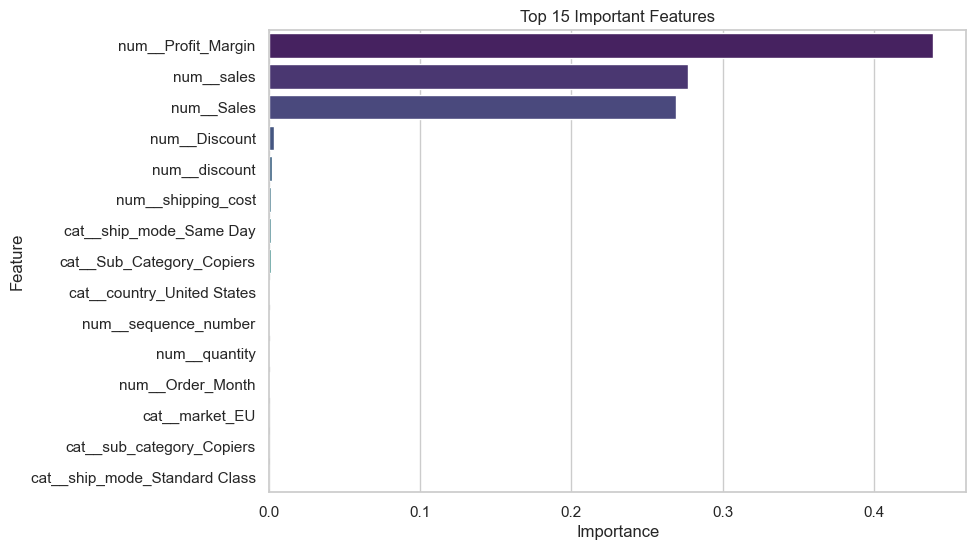

,Feature,Importance
9,num__Profit_Margin,0.439147
0,num__sales,0.277406
5,num__Sales,0.268953
6,num__Discount,0.003613
2,num__discount,0.002076
3,num__shipping_cost,0.001672
11,cat__ship_mode_Same Day,0.001416
212,cat__Sub_Category_Copiers,0.001200
151,cat__country_United States,0.000725
4,num__sequence_number,0.000594


In [67]:
if 'trained_pipes' in globals() and 'RandomForestRegressor' in trained_pipes:
    rf_pipe = trained_pipes['RandomForestRegressor']
else:
    rf_trees = 120 if ('FAST_MODE' in globals() and FAST_MODE) else 250
    rf_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=rf_trees,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])
    rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

fi = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi = fi.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi, y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Important Features')
plt.show()

fi

## Lesson 13: Storytelling and Conclusion

Use this format for your project report:
1. Data overview
2. Key trends
3. Profit leak areas
4. ML model performance
5. Business action plan

Now we add two new practical sections:
- Advanced but easy learning (classification + clustering)
- MIS section for management reporting

In [68]:
story = []

if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    top_sales_category = df.groupby('Category')['Sales'].sum().idxmax()
    top_profit_category = df.groupby('Category')['Profit'].sum().idxmax()
    story.append('Top sales category: ' + str(top_sales_category))
    story.append('Top profit category: ' + str(top_profit_category))

if {'Sub_Category', 'Profit'}.issubset(df.columns):
    worst_sub = df.groupby('Sub_Category')['Profit'].sum().idxmin()
    story.append('Most loss-making sub-category: ' + str(worst_sub))

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    story.append('Best model: ' + str(row['Model']) + ' with R2 = ' + str(round(row['R2'], 3)))

story.append('Action: control high discounts, improve weak sub-categories, and use model predictions for decision support.')

print('Final Storytelling Points:')
for i, s in enumerate(story, start=1):
    print(str(i) + '. ' + s)

Final Storytelling Points:
1. Top sales category: Technology
2. Top profit category: Technology
3. Most loss-making sub-category: Tables
4. Best model: RandomForestRegressor with R2 = 0.865
5. Action: control high discounts, improve weak sub-categories, and use model predictions for decision support.


## Final Wrap-Up

Great work. You completed a full data science workflow:
- Data cleaning
- Visual analysis
- Business insight discovery
- Machine learning model building
- Storytelling and recommendations
- MIS management reporting

You now learned from basic to advanced, but in a simple step-by-step style.

Next practice idea:
Try adding a sales forecasting model for next month revenue.

## Lesson 14: Advanced but Easy - Classification (Loss or Not Loss)

What is classification?
- It predicts classes (labels), not numbers.
- Here label is:
  - `1` = loss-making order (Profit < 0)
  - `0` = non-loss order

Why this is useful:
- Management can identify risky orders early and reduce losses.

In [69]:
# Create classification target
y_class = (df['Profit'] < 0).astype(int)

# Reuse X from regression section and align target rows.
y_class_aligned = y_class.loc[X.index]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class_aligned, test_size=0.2, random_state=42, stratify=y_class_aligned
)

clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

clf_pipe.fit(X_train_c, y_train_c)
pred_c = clf_pipe.predict(X_test_c)

acc = accuracy_score(y_test_c, pred_c)
f1 = f1_score(y_test_c, pred_c, zero_division=0)
print('Classification Accuracy:', round(acc, 4))
print('Classification F1 Score:', round(f1, 4))

Classification Accuracy: 0.995
Classification F1 Score: 0.9898


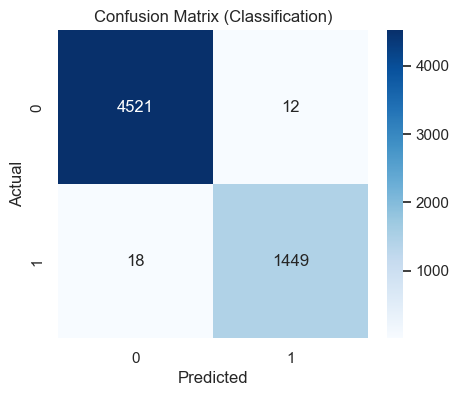

Quick report:
              precision    recall  f1-score   support

           0      0.996     0.997     0.997      4533
           1      0.992     0.988     0.990      1467

    accuracy                          0.995      6000
   macro avg      0.994     0.993     0.993      6000
weighted avg      0.995     0.995     0.995      6000



In [70]:
cm = confusion_matrix(y_test_c, pred_c)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Classification)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Quick report:')
print(classification_report(y_test_c, pred_c, digits=3))

## Lesson 15: Advanced but Easy - Unsupervised Learning (Clustering)

What is unsupervised learning?
- There is no target answer column.
- The model groups similar rows automatically.

We will use KMeans with simple numeric columns.
This helps identify groups of order behavior for business strategy.

,Sales,Profit,Discount
Cluster,,,
0,193.983519,38.235524,0.041175
1,2367.496933,558.757011,0.063804
2,143.295814,-65.755230,0.510791


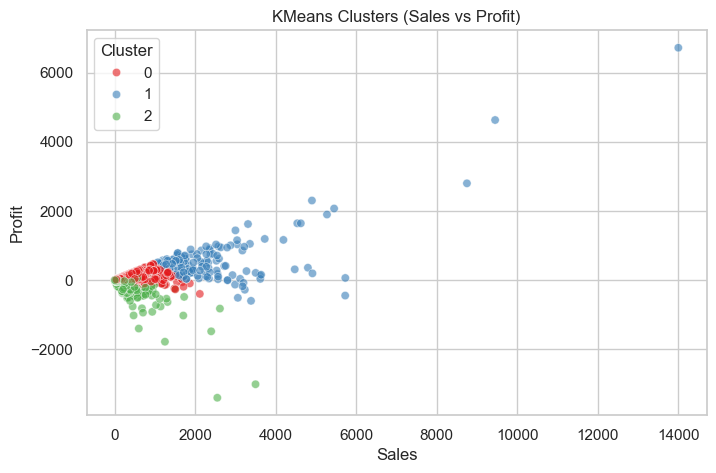

In [71]:
cluster_cols = [c for c in ['Sales', 'Profit', 'Discount'] if c in df.columns]

if len(cluster_cols) >= 2:
    cluster_data = df[cluster_cols].dropna().copy()

    # Keep this memory-safe and beginner-friendly
    if len(cluster_data) > 5000:
        cluster_data = cluster_data.sample(5000, random_state=42)

    scaler_cluster = StandardScaler()
    X_cluster = scaler_cluster.fit_transform(cluster_data)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_label = kmeans.fit_predict(X_cluster)

    cluster_data['Cluster'] = cluster_label
    display(cluster_data.groupby('Cluster').mean(numeric_only=True))

    plt.figure(figsize=(8, 5))
    if {'Sales', 'Profit'}.issubset(cluster_data.columns):
        sns.scatterplot(data=cluster_data, x='Sales', y='Profit', hue='Cluster', alpha=0.6, palette='Set1')
        plt.title('KMeans Clusters (Sales vs Profit)')
        plt.show()
else:
    print('Not enough numeric columns for clustering.')

## Lesson 16: MIS - Management Information System Section

MIS means summary reports for managers to take decisions quickly.

In this section we create:
- KPI summary (Sales, Profit, Orders, Profit Margin)
- Monthly MIS report
- Region MIS report
- Category MIS report
- Top and Bottom products by profit

In [72]:
total_sales = df['Sales'].sum() if 'Sales' in df.columns else np.nan
total_profit = df['Profit'].sum() if 'Profit' in df.columns else np.nan
total_orders = len(df)
profit_margin = (total_profit / total_sales) if ('Sales' in df.columns and total_sales != 0) else np.nan

kpi_df = pd.DataFrame({
    'KPI': ['Total Sales', 'Total Profit', 'Total Orders', 'Profit Margin'],
    'Value': [total_sales, total_profit, total_orders, profit_margin]
})

print('MIS KPI Summary')
display(kpi_df)

MIS KPI Summary


,KPI,Value
0,Total Sales,1.264290e+07
1,Total Profit,1.469035e+06
2,Total Orders,5.129000e+04
3,Profit Margin,1.161944e-01


In [73]:
if {'Order_Date', 'Sales', 'Profit'}.issubset(df.columns):
    monthly_mis = (
        df.set_index('Order_Date')
          .resample('M')[['Sales', 'Profit']]
          .sum()
          .reset_index()
    )
    print('Monthly MIS Report')
    display(monthly_mis.tail(12))

if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    region_mis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Region MIS Report')
    display(region_mis)

if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    category_mis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    print('Category MIS Report')
    display(category_mis)

Monthly MIS Report


,Order_Date,Sales,Profit
36,2014-01-31,268275,31447.74660
37,2014-02-28,244179,29454.01876
38,2014-03-31,347757,50097.04458
39,2014-04-30,302140,35709.53320
40,2014-05-31,304795,34335.60404
41,2014-06-30,372608,40869.02108
42,2014-07-31,278670,26450.70856
43,2014-08-31,432742,46443.47934
44,2014-09-30,405455,52533.83284
45,2014-10-31,406676,52342.49740


Region MIS Report


,Sales,Profit
Region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,121666.64200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


Category MIS Report


,Sales,Profit
Category,,
Technology,4744691,663778.73318
Furniture,4110884,286782.25380
Office Supplies,3787330,518473.83430


In [74]:
if {'Product_Name', 'Profit', 'Sales'}.issubset(df.columns):
    product_mis = df.groupby('Product_Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)

    print('Top 10 Products by Profit')
    display(product_mis.head(10))

    print('Bottom 10 Products by Profit (loss heavy)')
    display(product_mis.tail(10).sort_values('Profit', ascending=True))

Top 10 Products by Profit


,Sales,Profit
Product_Name,,
Canon imageCLASS 2200 Advanced Copier,61600,25199.9280
"Cisco Smart Phone, Full Size",76441,17238.5206
"Motorola Smart Phone, Full Size",73159,17027.1130
"Hoover Stove, Red",31664,11807.9690
"Sauder Classic Bookcase, Traditional",39110,10672.0730
"Harbour Creations Executive Leather Armchair, Adjustable",50120,10427.3260
"Nokia Smart Phone, Full Size",71904,9938.1955
"Cisco Smart Phone, with Caller ID",43124,9786.6408
"Nokia Smart Phone, with Caller ID",47880,9465.3257


Bottom 10 Products by Profit (loss heavy)


,Sales,Profit
Product_Name,,
Cubify CubeX 3D Printer Double Head Print,11100,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16830,-4589.9730
"Motorola Smart Phone, Cordless",38935,-4447.0380
Cubify CubeX 3D Printer Triple Head Print,8000,-3839.9904
"Bevis Round Table, Adjustable Height",5655,-3649.8940
"Bevis Computer Table, Fully Assembled",11176,-3509.5638
"Rogers Lockers, Blue",28215,-2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9918,-2876.1156
"Bevis Wood Table, with Bottom Storage",11134,-2782.5880
